CONFIGURATION

In [2]:
import sys
sys.path.append("..")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from src.db import get_engine

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})
fmt_num = FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))

def save(fig, name):
    """Enregistre la figure (réutilisable dans le README)."""
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

engine = get_engine()

CHARGEMENT ET CONTÔLES

In [3]:
orders = pd.read_sql("SELECT * FROM analytics.v_orders", engine,
                     parse_dates=["order_date", "order_month"])
sales = pd.read_sql("SELECT * FROM analytics.fact_sales", engine,
                    parse_dates=["order_date", "order_month"])
rfm = pd.read_sql("SELECT * FROM analytics.rfm_segments", engine)
ts = pd.read_sql("SELECT order_id, order_purchase_timestamp FROM clean.orders WHERE in_scope",
                 engine, parse_dates=["order_purchase_timestamp"])

# Contrôles : on doit retrouver exactement les chiffres du SQL
assert len(orders) == 96211, len(orders)
assert len(rfm) == 93104, len(rfm)
assert abs(orders["revenue"].sum() - 13181027.13) < 0.01
print("Chargement OK :", len(orders), "commandes,", len(sales), "lignes,", len(rfm), "clients")
print(orders.dtypes)

Chargement OK : 96211 commandes, 109880 lignes, 93104 clients
order_id                        str
order_date            datetime64[s]
order_month           datetime64[s]
customer_unique_id              str
customer_state                  str
customer_city                   str
units                         int64
revenue                     float64
freight                     float64
dtype: object


DISTRIBUTION DE LA VALEUR DES COMMANDES

count    96211.00
mean       137.00
std        209.11
min          0.85
25%         45.90
50%         86.50
75%        149.90
90%        269.00
99%        991.71
max      13440.00
Name: revenue, dtype: float64

Commandes au-dessus du 99e percentile (992 BRL) : 963 | part du CA : 11.5%


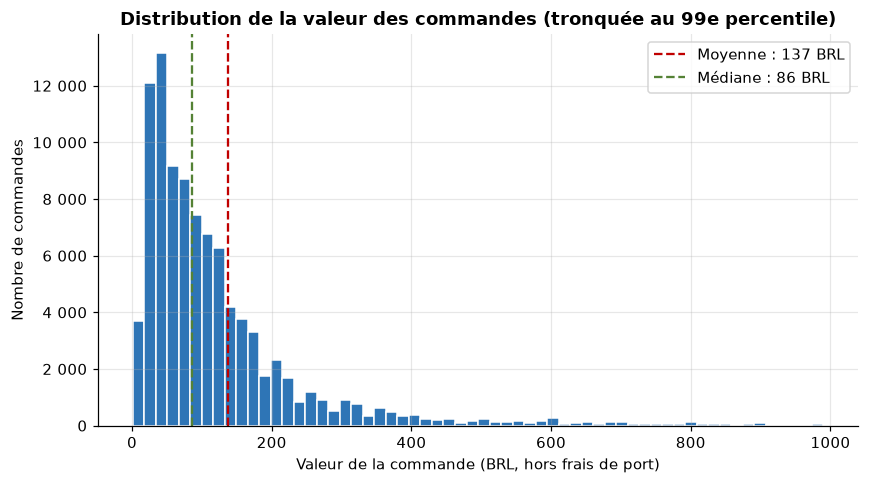

In [4]:
v = orders["revenue"]
print(v.describe(percentiles=[.25, .5, .75, .9, .99]).round(2))
cap = v.quantile(0.99)
print(f"\nCommandes au-dessus du 99e percentile ({cap:,.0f} BRL) : {(v > cap).sum():,}"
      f" | part du CA : {v[v > cap].sum() / v.sum():.1%}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(v[v <= cap], bins=60, color="#2E75B6", edgecolor="white")
ax.axvline(v.mean(), color="#C00000", ls="--", label=f"Moyenne : {v.mean():,.0f} BRL")
ax.axvline(v.median(), color="#548235", ls="--", label=f"Médiane : {v.median():,.0f} BRL")
ax.set_title("Distribution de la valeur des commandes (tronquée au 99e percentile)")
ax.set_xlabel("Valeur de la commande (BRL, hors frais de port)")
ax.set_ylabel("Nombre de commandes")
ax.yaxis.set_major_formatter(fmt_num)
ax.legend()
save(fig, "01_order_value_distribution")
plt.show()

ÉVOLUTION TEMPORELLE

order_month  revenue  orders
    2017-01 111798.0     750
    2017-02 234223.0    1653
    2017-03 359199.0    2546
    2017-04 340670.0    2303
    2017-05 489338.0    3546
    2017-06 421923.0    3135
    2017-07 481605.0    3872
    2017-08 554700.0    4193
    2017-09 607400.0    4150
    2017-10 648248.0    4478
    2017-11 987765.0    7289
    2017-12 726033.0    5513
    2018-01 924645.0    7069
    2018-02 826437.0    6555
    2018-03 953356.0    7003
    2018-04 973534.0    6798
    2018-05 977545.0    6749
    2018-06 856078.0    6099
    2018-07 867953.0    6159
    2018-08 838577.0    6351


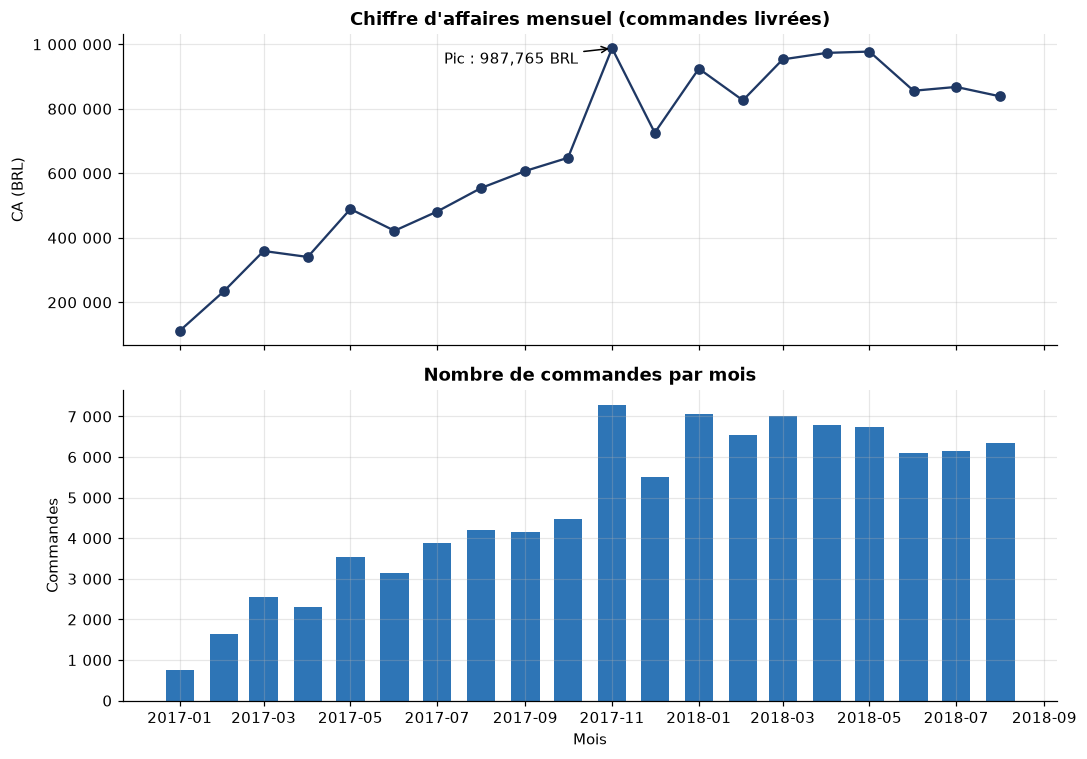

In [5]:
monthly = (orders.groupby("order_month")
           .agg(revenue=("revenue", "sum"), orders=("order_id", "count"))
           .reset_index())
print(monthly.assign(order_month=monthly["order_month"].dt.strftime("%Y-%m"))
             .round({"revenue": 0})
             .to_string(index=False))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
ax1.plot(monthly["order_month"], monthly["revenue"], marker="o", color="#1F3864")
ax1.set_title("Chiffre d'affaires mensuel (commandes livrées)")
ax1.set_ylabel("CA (BRL)")
ax1.yaxis.set_major_formatter(fmt_num)
peak = monthly.loc[monthly["revenue"].idxmax()]
ax1.annotate(f"Pic : {peak['revenue']:,.0f} BRL",
             xy=(peak["order_month"], peak["revenue"]),
             xytext=(-110, -10), textcoords="offset points",
             arrowprops=dict(arrowstyle="->"))

ax2.bar(monthly["order_month"], monthly["orders"], width=20, color="#2E75B6")
ax2.set_title("Nombre de commandes par mois")
ax2.set_xlabel("Mois")
ax2.set_ylabel("Commandes")
ax2.yaxis.set_major_formatter(fmt_num)
save(fig, "02_monthly_evolution")
plt.show()

In [ ]:
SAISONNABILITÉ HEBDOMAIRE ET HORAIRE

Part des commandes par jour (%) : {'Lun': 16.3, 'Mar': 16.1, 'Mer': 15.6, 'Jeu': 14.8, 'Ven': 14.2, 'Sam': 10.9, 'Dim': 12.1}
Part des commandes par heure (%) : {0: np.float64(2.4), 1: np.float64(1.2), 2: np.float64(0.5), 3: np.float64(0.3), 4: np.float64(0.2), 5: np.float64(0.2), 6: np.float64(0.5), 7: np.float64(1.2), 8: np.float64(3.0), 9: np.float64(4.8), 10: np.float64(6.2), 11: np.float64(6.6), 12: np.float64(6.0), 13: np.float64(6.5), 14: np.float64(6.6), 15: np.float64(6.5), 16: np.float64(6.7), 17: np.float64(6.2), 18: np.float64(5.8), 19: np.float64(6.0), 20: np.float64(6.2), 21: np.float64(6.3), 22: np.float64(5.9), 23: np.float64(4.2)}


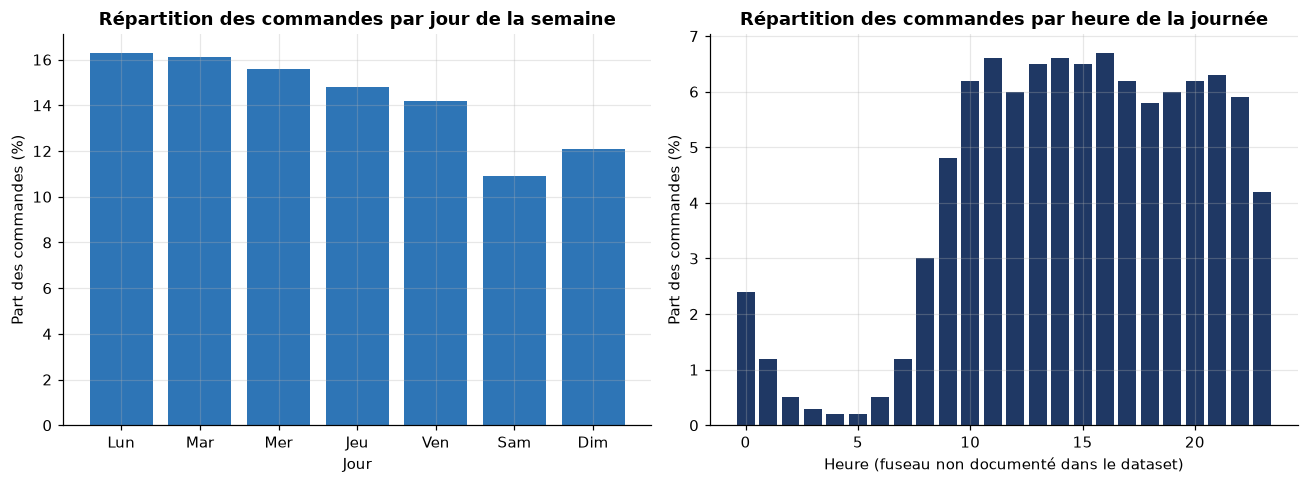

In [6]:
ts["weekday"] = ts["order_purchase_timestamp"].dt.dayofweek
ts["hour"] = ts["order_purchase_timestamp"].dt.hour
days = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

by_wd = ts.groupby("weekday").size().reindex(range(7))
by_hour = ts.groupby("hour").size().reindex(range(24), fill_value=0)
wd_pct = (by_wd / by_wd.sum() * 100).round(1)
hour_pct = (by_hour / by_hour.sum() * 100).round(1)
print("Part des commandes par jour (%) :", dict(zip(days, wd_pct)))
print("Part des commandes par heure (%) :", dict(hour_pct))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.bar(days, wd_pct, color="#2E75B6")
ax1.set_title("Répartition des commandes par jour de la semaine")
ax1.set_xlabel("Jour")
ax1.set_ylabel("Part des commandes (%)")
ax2.bar(by_hour.index, hour_pct, color="#1F3864")
ax2.set_title("Répartition des commandes par heure de la journée")
ax2.set_xlabel("Heure (fuseau non documenté dans le dataset)")
ax2.set_ylabel("Part des commandes (%)")
save(fig, "03_weekday_hour_pattern")
plt.show()

COMPORTEMENT CLIENT

                      customers    revenue  pct_customers  pct_revenue
segment                                                               
Champions                   833   274905.9            0.9          2.1
Loyal Customers             600   117979.0            0.6          0.9
Potential Loyalists       36263  5100101.6           38.9         38.7
Occasional Customers      18273  2399119.1           19.6         18.2
At Risk                   14464  4017320.0           15.5         30.5
Lost Customers            22671  1271601.5           24.4          9.6


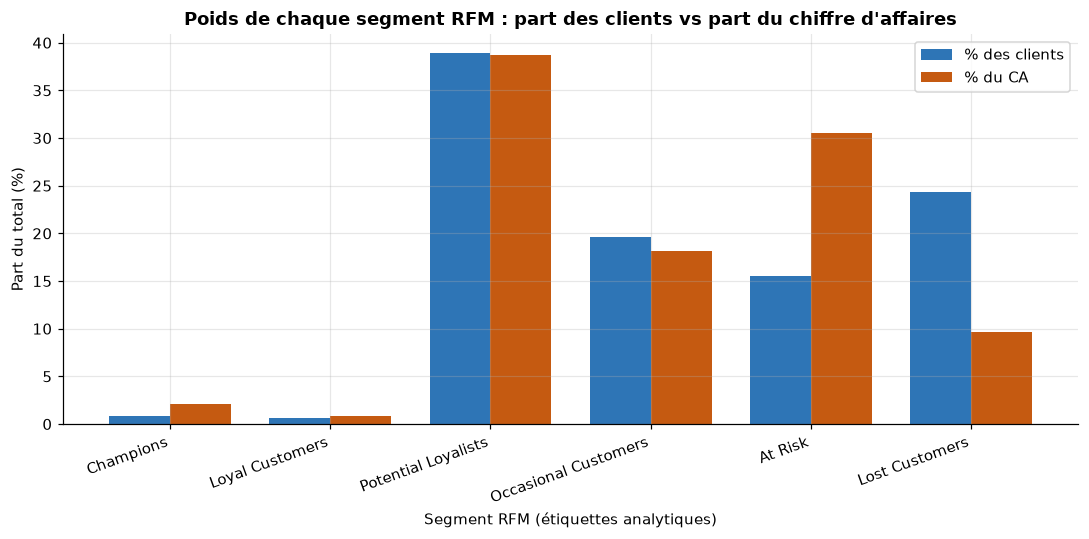

In [7]:
order_seg = ["Champions", "Loyal Customers", "Potential Loyalists",
             "Occasional Customers", "At Risk", "Lost Customers"]
seg = (rfm.groupby("segment")
       .agg(customers=("customer_unique_id", "count"), revenue=("monetary", "sum"))
       .reindex(order_seg))
seg["pct_customers"] = seg["customers"] / seg["customers"].sum() * 100
seg["pct_revenue"] = seg["revenue"] / seg["revenue"].sum() * 100
print(seg.round(1))

x = np.arange(len(seg))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w / 2, seg["pct_customers"], w, label="% des clients", color="#2E75B6")
ax.bar(x + w / 2, seg["pct_revenue"], w, label="% du CA", color="#C55A11")
ax.set_xticks(x)
ax.set_xticklabels(seg.index, rotation=20, ha="right")
ax.set_title("Poids de chaque segment RFM : part des clients vs part du chiffre d'affaires")
ax.set_xlabel("Segment RFM (étiquettes analytiques)")
ax.set_ylabel("Part du total (%)")
ax.legend()
save(fig, "04_rfm_segments")
plt.show()

PERFORMANCE DES PRODUITS (PARETO DES CATÉGORIES)

18 catégories sur 74 (24%) atteignent 80 % du CA


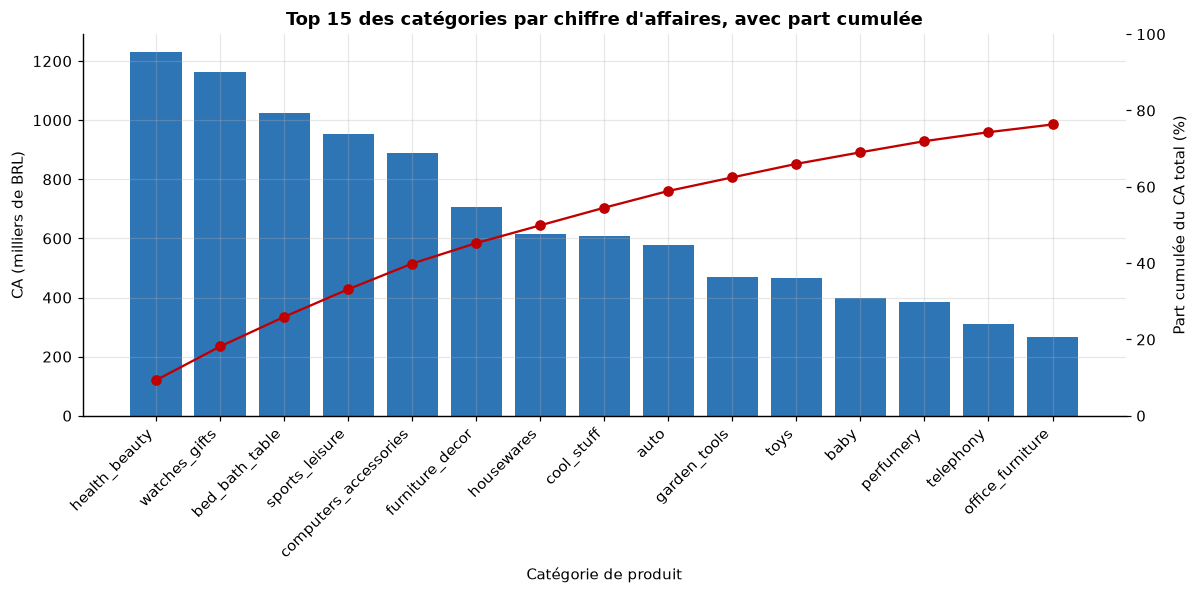

In [8]:
cat = sales.groupby("category")["revenue"].sum().sort_values(ascending=False)
cum_pct = cat.cumsum() / cat.sum() * 100
n80 = int((cum_pct < 80).sum() + 1)
print(f"{n80} catégories sur {len(cat)} ({n80 / len(cat):.0%}) atteignent 80 % du CA")

top = cat.head(15)
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(range(len(top)), top.values / 1000, color="#2E75B6")
ax.set_xticks(range(len(top)))
ax.set_xticklabels(top.index, rotation=45, ha="right")
ax.set_title("Top 15 des catégories par chiffre d'affaires, avec part cumulée")
ax.set_xlabel("Catégorie de produit")
ax.set_ylabel("CA (milliers de BRL)")
ax2 = ax.twinx()
ax2.plot(range(len(top)), cum_pct.head(15).values, color="#C00000", marker="o")
ax2.set_ylabel("Part cumulée du CA total (%)")
ax2.set_ylim(0, 100)
ax2.grid(False)
save(fig, "05_category_pareto")
plt.show()

CORRELATIONS PERTINENTES

             revenue  freight  units  freight_pct
revenue         1.00     0.47   0.18        -0.78
freight         0.47     1.00   0.38         0.10
units           0.18     0.38   1.00         0.08
freight_pct    -0.78     0.10   0.08         1.00

  value_decile  median_value  median_freight_pct
            1          19.0                73.1
            2          30.0                46.0
            3          46.0                33.6
            4          59.6                27.4
            5          76.0                21.8
            6          98.0                18.2
            7         119.9                15.6
            8         149.9                13.3
            9         204.0                10.5
           10         399.0                 6.4


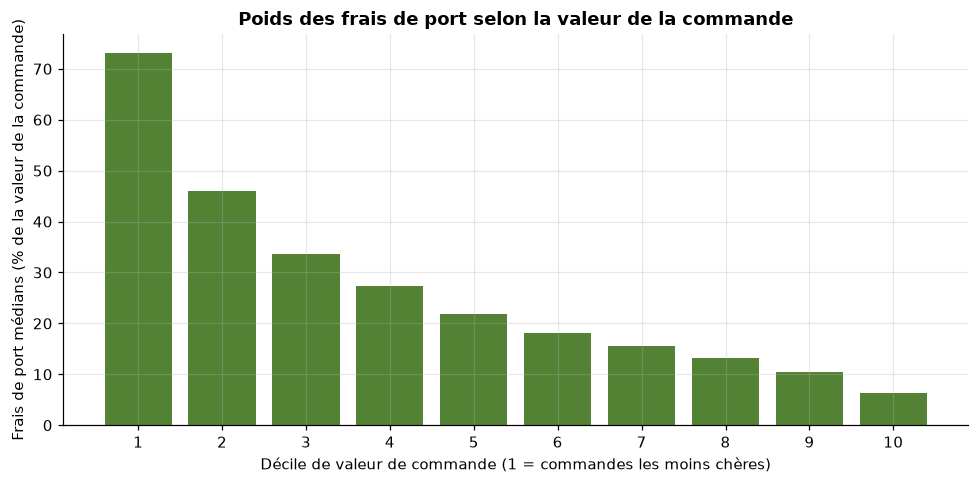

In [9]:
o = orders[orders["revenue"] > 0].copy()
o["freight_pct"] = o["freight"] / o["revenue"] * 100

# Spearman : les distributions sont très asymétriques, Pearson serait trompeur
print(o[["revenue", "freight", "units", "freight_pct"]].corr(method="spearman").round(2))

o["value_decile"] = pd.qcut(o["revenue"], 10, labels=False, duplicates="drop") + 1
g = (o.groupby("value_decile")
     .agg(median_value=("revenue", "median"), median_freight_pct=("freight_pct", "median"))
     .reset_index())
print("\n", g.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(g["value_decile"], g["median_freight_pct"], color="#548235")
ax.set_xticks(g["value_decile"])
ax.set_title("Poids des frais de port selon la valeur de la commande")
ax.set_xlabel("Décile de valeur de commande (1 = commandes les moins chères)")
ax.set_ylabel("Frais de port médians (% de la valeur de la commande)")
save(fig, "06_freight_vs_order_value")
plt.show()